<a href="https://colab.research.google.com/github/albertoverrilli/DeepLeaning-Time-Series-Data/blob/main/Final_project_DL4AI_task1_2_merged.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final project: Time-series data and application to stock markets {-}

This project aims at familiarizing you with time-series data analysis and its application to stock markets. Datasets you will be working on are Nasdaq and Vietnam stock datasets.

### Submission {-}
The structure of submission folder should be organized as follows:

- ./\<StudentID>-project-notebook.ipynb: Jupyter notebook containing source code.
- ./\<StudentID>-project-report.pdf: project report.

The submission folder is named DL4AI-\<StudentID>-project (e.g., DL4AI-2012345-project) and then compressed with the same name.

### Evaluation {-}
Project evaluation will be conducted on how you accomplish the assignment requirements. You can refer to the project instruction slide deck for details.

### Deadline {-}
Please visit Canvas for details.

# Setup

Shared setup used across all tasks below.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Input
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [32]:
# Load AAPL data
data_appl = pd.read_csv('/content/drive/MyDrive/selected_stocks/AAPL.csv')
data_appl.head()

,Date,Low,Open,Volume,High,Close,Adjusted Close
0,12-12-1980,0.128348,0.128348,469033600,0.128906,0.128348,0.099874
1,15-12-1980,0.121652,0.122210,175884800,0.122210,0.121652,0.094663
2,16-12-1980,0.112723,0.113281,105728000,0.113281,0.112723,0.087715
3,17-12-1980,0.115513,0.115513,86441600,0.116071,0.115513,0.089886
4,18-12-1980,0.118862,0.118862,73449600,0.119420,0.118862,0.092492


In [33]:
# Get some info about the data
data_appl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10590 entries, 0 to 10589
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            10590 non-null  object 
 1   Low             10590 non-null  float64
 2   Open            10590 non-null  float64
 3   Volume          10590 non-null  int64  
 4   High            10590 non-null  float64
 5   Close           10590 non-null  float64
 6   Adjusted Close  10590 non-null  float64
dtypes: float64(5), int64(1), object(1)
memory usage: 579.3+ KB


In [34]:
# Shared parameters used by all tasks
df = data_appl
window_size = 30  # 30-day lookback window

# Use multiple features instead of just Open price
features = ['Open', 'High', 'Low', 'Close', 'Adjusted Close', 'Volume']
feature_indices = [df.columns.get_loc(f) for f in features]

## Helper functions

These are used across all three tasks to avoid duplicating logic.

In [35]:
def per_window_normalize(X, y):
    """Per-window MinMax normalization. Prices and Volume normalized separately
    so Volume's large magnitude doesn't distort the price scale."""
    X_norm = X.copy().astype(float)
    y_norm = y.copy().astype(float)
    for i in range(len(X)):
        # Price columns (first 5)
        min_f = np.min(X[i, :, :5])
        max_f = np.max(X[i, :, :5])
        X_norm[i, :, :5] = (X[i, :, :5] - min_f) / (max_f - min_f)
        # Volume column (last)
        vol_min = np.min(X[i, :, 5])
        vol_max = np.max(X[i, :, 5])
        if vol_max - vol_min != 0:
            X_norm[i, :, 5] = (X[i, :, 5] - vol_min) / (vol_max - vol_min)
        # Label normalized using price min/max
        y_norm[i] = (y[i] - min_f) / (max_f - min_f)
    return X_norm, y_norm


def per_window_denormalize(y_norm, X_original):
    """Reverse per-window normalization to get back real dollar prices."""
    y_denorm = y_norm.copy()
    for i in range(len(y_denorm)):
        min_f = np.min(X_original[i, :, :5])
        max_f = np.max(X_original[i, :, :5])
        y_denorm[i] = y_norm[i] * (max_f - min_f) + min_f
    return y_denorm


def build_model(num_outputs):
    """Build the same Conv1D model used in the demo, with configurable output size."""
    model = tf.keras.Sequential()
    model.add(Input(shape=(window_size, len(features))))
    model.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(2))
    model.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(2))
    model.add(Flatten())
    model.add(Dense(100, activation='relu'))
    model.add(Dense(num_outputs))
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                  loss='mse', metrics=['mse'])
    return model

# Task 1.1 - Multi-feature extension

Modify the demo code so that the model utilizes multiple features (Low, High, Open, Close, Adjusted Close, Volume) instead of just the Open price.

In [36]:
### Split the dataset into time windows to get data samples
X_data = []
y_data = []

for i in range(1, len(df) - window_size - 1):
    data_feature = []
    data_label = []

    # Get a window_size time frame for data feature (now grabs all 6 features)
    for j in range(window_size):
        data_feature.append(df.iloc[i + j, feature_indices].values)

    # Next value is the label (Close price of the next day) to be predicted
    data_label.append(df.iloc[i + window_size]['Close'])

    X_data.append(np.array(data_feature).reshape(window_size, len(features)))
    y_data.append(np.array(data_label))

In [37]:
### Split the data into training, validation and test set
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, shuffle=False)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, shuffle=False)

X_train = np.array(X_train); X_val = np.array(X_val); X_test = np.array(X_test)
y_train = np.array(y_train); y_val = np.array(y_val); y_test = np.array(y_test)

# Reshape to fit the neural network input shape requirement
X_train = X_train.reshape(X_train.shape[0], window_size, len(features))
X_val   = X_val.reshape(X_val.shape[0],   window_size, len(features))
X_test  = X_test.reshape(X_test.shape[0],  window_size, len(features))

print("Shape of training set:   ", X_train.shape)
print("Shape of validation set: ", X_val.shape)
print("Shape of test set:       ", X_test.shape)

Shape of training set:    (6756, 30, 6)
Shape of validation set:  (1690, 30, 6)
Shape of test set:        (2112, 30, 6)


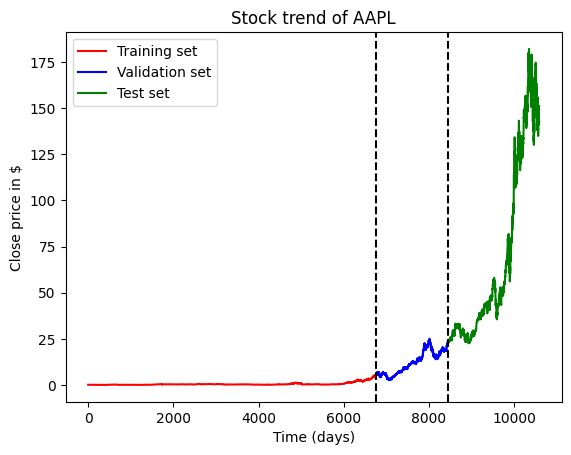

In [38]:
# Visualize the training, validation and test set splits
df_plot = df['Close'].reset_index(drop=False)
size_train = X_train.shape[0]
size_val = X_val.shape[0]

ax = df_plot.iloc[:size_train, 1:2].plot(y=0, color='red', label='Training set')
df_plot.iloc[size_train:size_train+size_val, 1:2].plot(y=0, color='blue', label='Validation set', ax=ax)
df_plot.iloc[size_train+size_val:, 1:2].plot(y=0, color='green', label='Test set', ax=ax)
ax.set_title("Stock trend of AAPL")
plt.xlabel('Time (days)')
plt.ylabel('Close price in $')
plt.axvline(x=size_train, color='black', linestyle='--')
plt.axvline(x=size_train+size_val, color='black', linestyle='--')
plt.show()

In [39]:
# Per-window normalization
X_train_norm, y_train_norm = per_window_normalize(X_train, y_train)
X_val_norm,   y_val_norm   = per_window_normalize(X_val,   y_val)
X_test_norm,  y_test_norm  = per_window_normalize(X_test,  y_test)

In [40]:
### Create and train the model for Task 1.1
model_11 = build_model(num_outputs=1)
history_11 = model_11.fit(X_train_norm, y_train_norm,
                          validation_data=(X_val_norm, y_val_norm),
                          epochs=10, batch_size=512)

Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.6090 - mse: 0.6090 - val_loss: 0.0488 - val_mse: 0.0488
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0556 - mse: 0.0556 - val_loss: 0.0404 - val_mse: 0.0404
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0286 - mse: 0.0286 - val_loss: 0.0121 - val_mse: 0.0121
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0131 - mse: 0.0131 - val_loss: 0.0093 - val_mse: 0.0093
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0137 - mse: 0.0137 - val_loss: 0.0095 - val_mse: 0.0095
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0110 - mse: 0.0110 - val_loss: 0.0076 - val_mse: 0.0076
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0093 - mse: 0.0093 - val_loss: 0.0062 - val_mse: 0.0062
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0082 - mse: 0.0082 - val_loss: 0.0059 - val_mse: 0.0059
Epoch 9/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.007

In [41]:
### Get prediction on the test data
y_pred_norm_11 = model_11.predict(X_test_norm)
mse_11 = mean_squared_error(y_pred_norm_11, y_test_norm)
rmse_11_norm = np.sqrt(mse_11)
print("MSE on the test set:  ", mse_11)
print("RMSE on the test set: ", rmse_11_norm)

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MSE on the test set:   0.012587062689425702
RMSE on the test set:  0.11219207944157958


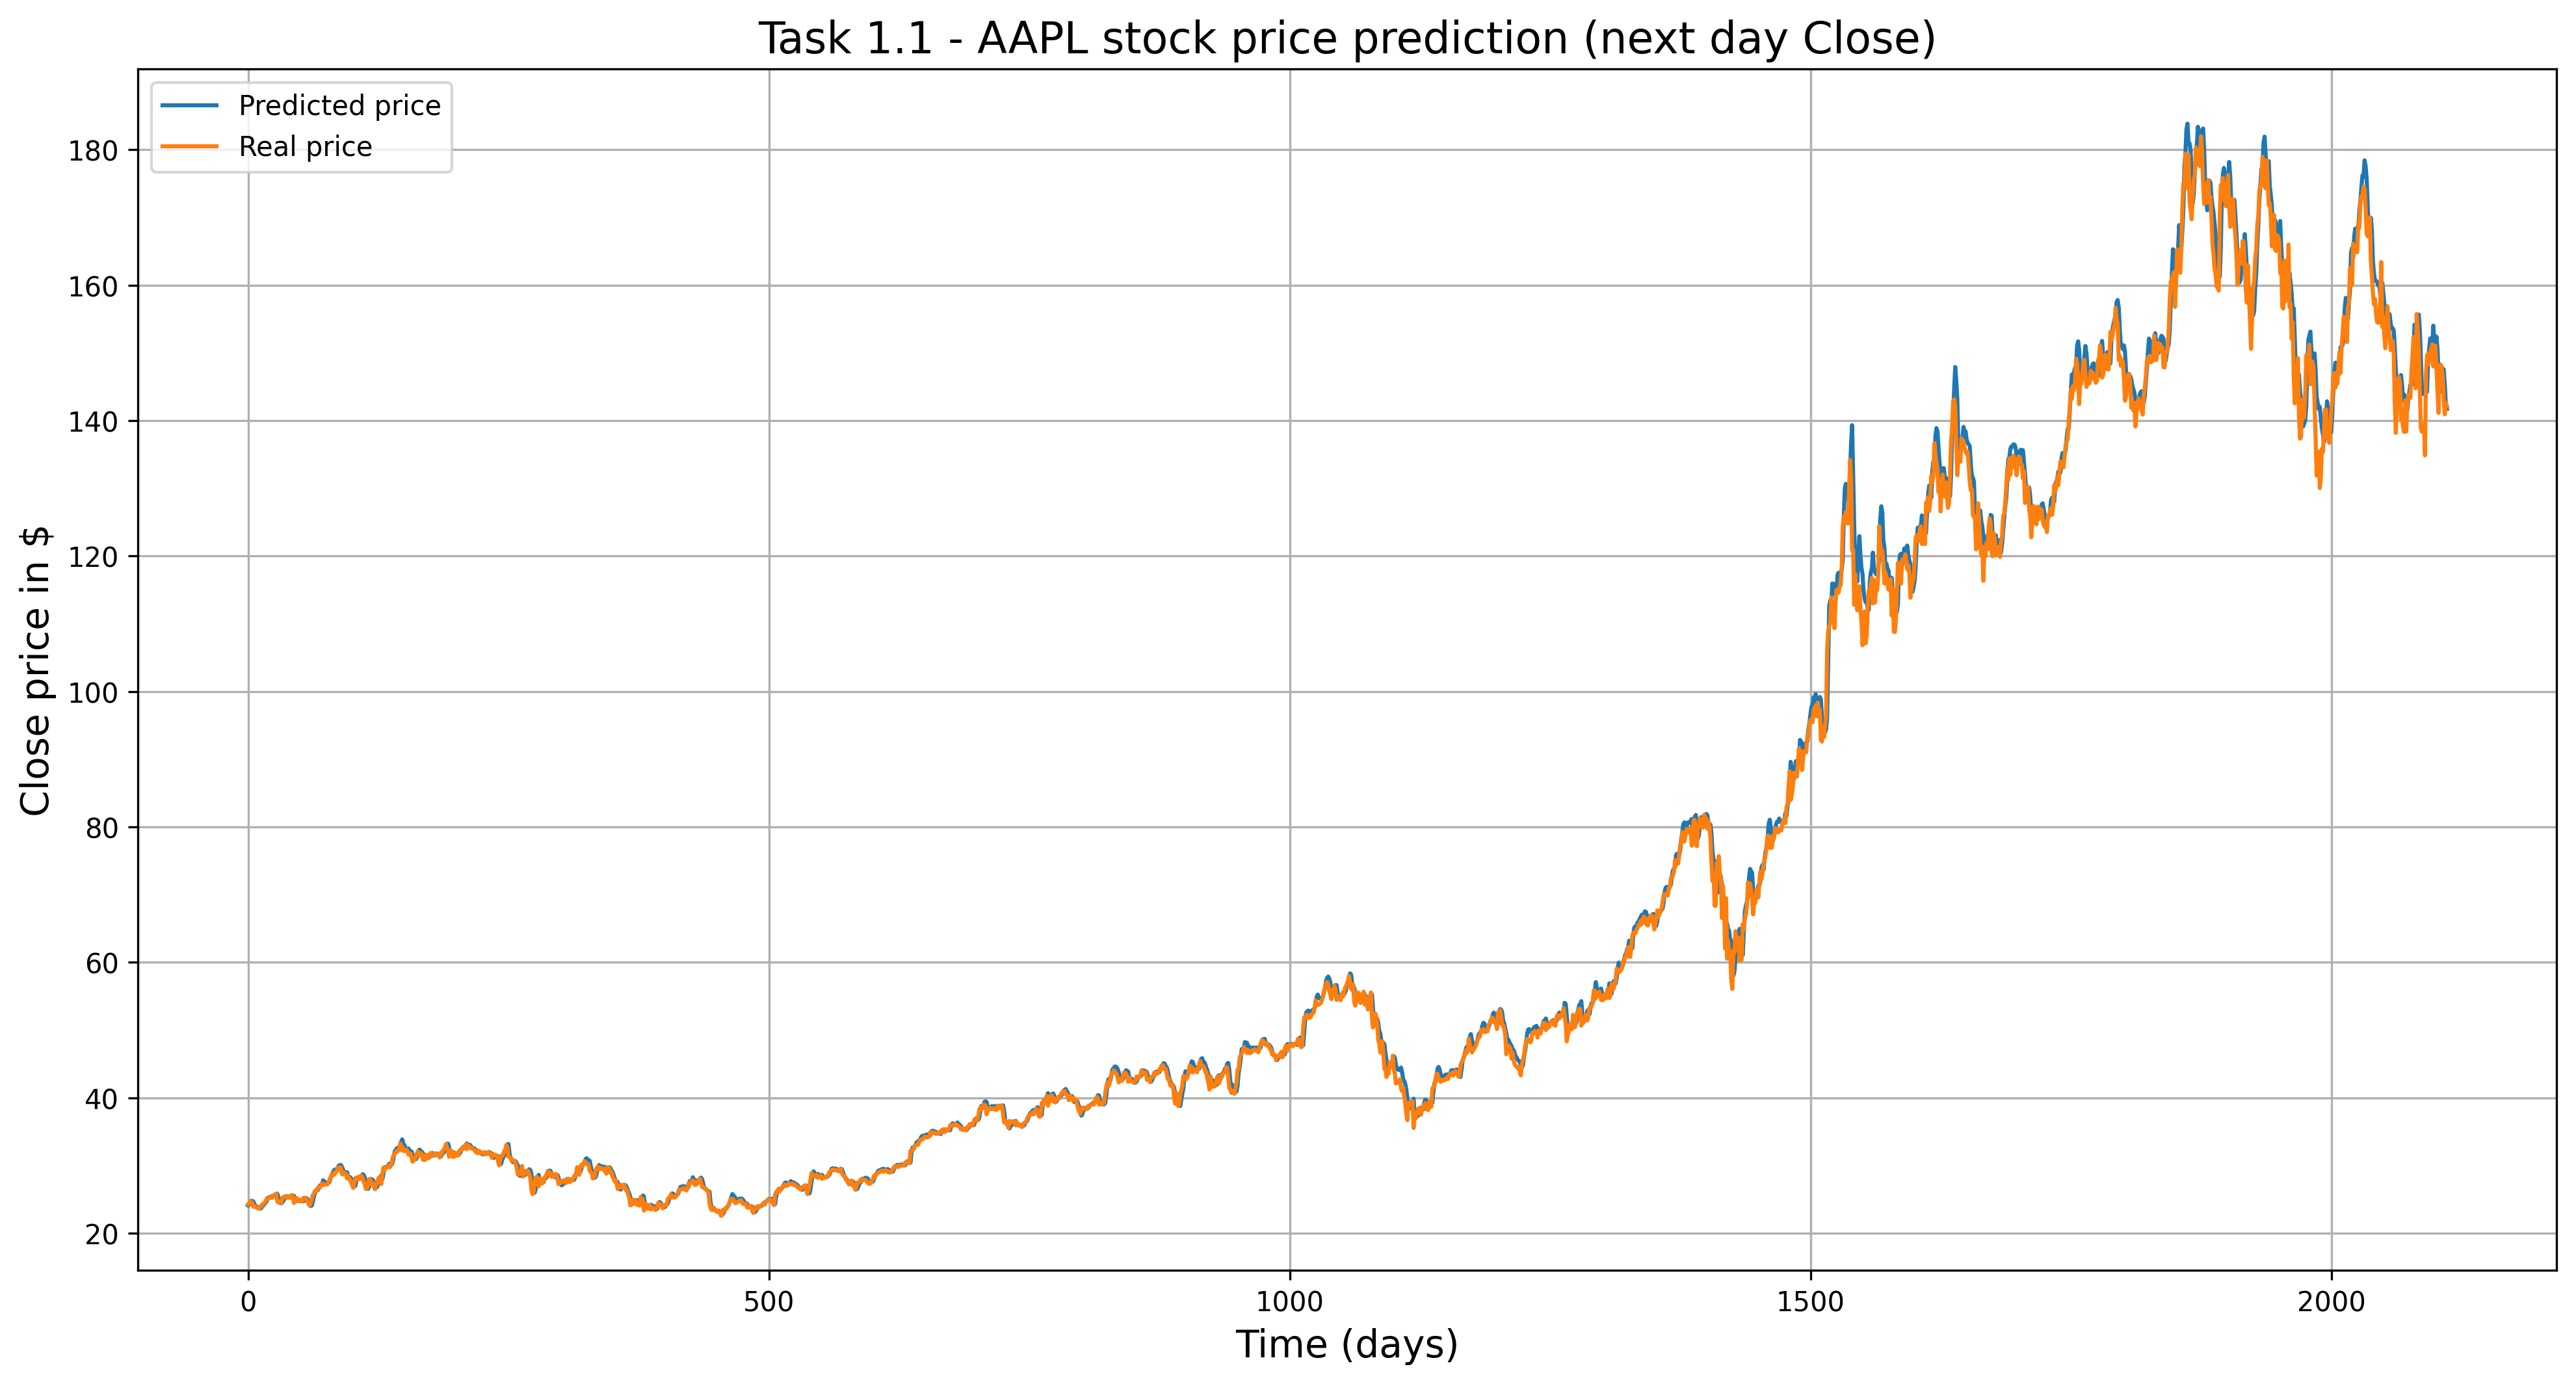

In [ ]:
# Convert the result back to stock price for visualization purpose
y_pred_denorm_11 = per_window_denormalize(y_pred_norm_11, X_test)
y_test_denorm_11 = per_window_denormalize(y_test_norm,    X_test)

plt.figure(figsize=(16, 8), dpi=300)
plt.plot(y_pred_denorm_11, label='Predicted price')
plt.plot(y_test_denorm_11, label='Real price')
plt.title('Task 1.1 - AAPL stock price prediction (next day Close)', fontsize=16)
plt.xlabel('Time (days)', fontsize=14)
plt.ylabel('Close price in $', fontsize=14)
plt.grid()
plt.legend()
plt.show()

# Task 1.2 - Nth day ahead forecast

Update the model to forecast the price on the Nth day in the future (e.g., 3rd or 7th day ahead) instead of just the next day. Builds on Task 1.1's multi-feature approach.

In [ ]:
### Window creation with Nth day label
N = 3  # Predict the Nth day ahead (change to 7 for 7th day prediction)

X_data = []
y_data = []

# Range adjusted by N to avoid going out of bounds
for i in range(1, len(df) - window_size - N):
    data_feature = []
    data_label = []

    for j in range(window_size):
        data_feature.append(df.iloc[i + j, feature_indices].values)

    # Label is the Close price on the Nth day ahead
    data_label.append(df.iloc[i + window_size + N - 1]['Close'])

    X_data.append(np.array(data_feature).reshape(window_size, len(features)))
    y_data.append(np.array(data_label))

In [ ]:
### Split, reshape and normalize (identical to Task 1.1)
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, shuffle=False)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, shuffle=False)

X_train = np.array(X_train); X_val = np.array(X_val); X_test = np.array(X_test)
y_train = np.array(y_train); y_val = np.array(y_val); y_test = np.array(y_test)

X_train = X_train.reshape(X_train.shape[0], window_size, len(features))
X_val   = X_val.reshape(X_val.shape[0],   window_size, len(features))
X_test  = X_test.reshape(X_test.shape[0],  window_size, len(features))

X_train_norm, y_train_norm = per_window_normalize(X_train, y_train)
X_val_norm,   y_val_norm   = per_window_normalize(X_val,   y_val)
X_test_norm,  y_test_norm  = per_window_normalize(X_test,  y_test)

print("Shape of training set:   ", X_train.shape)
print("Shape of validation set: ", X_val.shape)
print("Shape of test set:       ", X_test.shape)

Shape of training set:    (6755, 30, 6)
Shape of validation set:  (1689, 30, 6)
Shape of test set:        (2112, 30, 6)


In [ ]:
### Create and train the model for Task 1.2
model_12 = build_model(num_outputs=1)
history_12 = model_12.fit(X_train_norm, y_train_norm,
                          validation_data=(X_val_norm, y_val_norm),
                          epochs=5, batch_size=512)

Epoch 1/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - loss: 0.6642 - mse: 0.6642 - val_loss: 0.0668 - val_mse: 0.0668
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 0.0760 - mse: 0.0760 - val_loss: 0.0541 - val_mse: 0.0541
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - loss: 0.0660 - mse: 0.0660 - val_loss: 0.0521 - val_mse: 0.0521
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - loss: 0.0632 - mse: 0.0632 - val_loss: 0.0520 - val_mse: 0.0520
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0612 - mse: 0.0612 - val_loss: 0.0570 - val_mse: 0.0570


In [ ]:
### Get prediction on the test data
y_pred_norm_12 = model_12.predict(X_test_norm)
mse_12 = mean_squared_error(y_pred_norm_12, y_test_norm)
rmse_12_norm = np.sqrt(mse_12)
print(f"Predicting {N} days ahead")
print("MSE on the test set:  ", mse_12)
print("RMSE on the test set: ", rmse_12_norm)

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Predicting 3 days ahead
MSE on the test set:   0.10053777914672955
RMSE on the test set:  0.31707692938264925


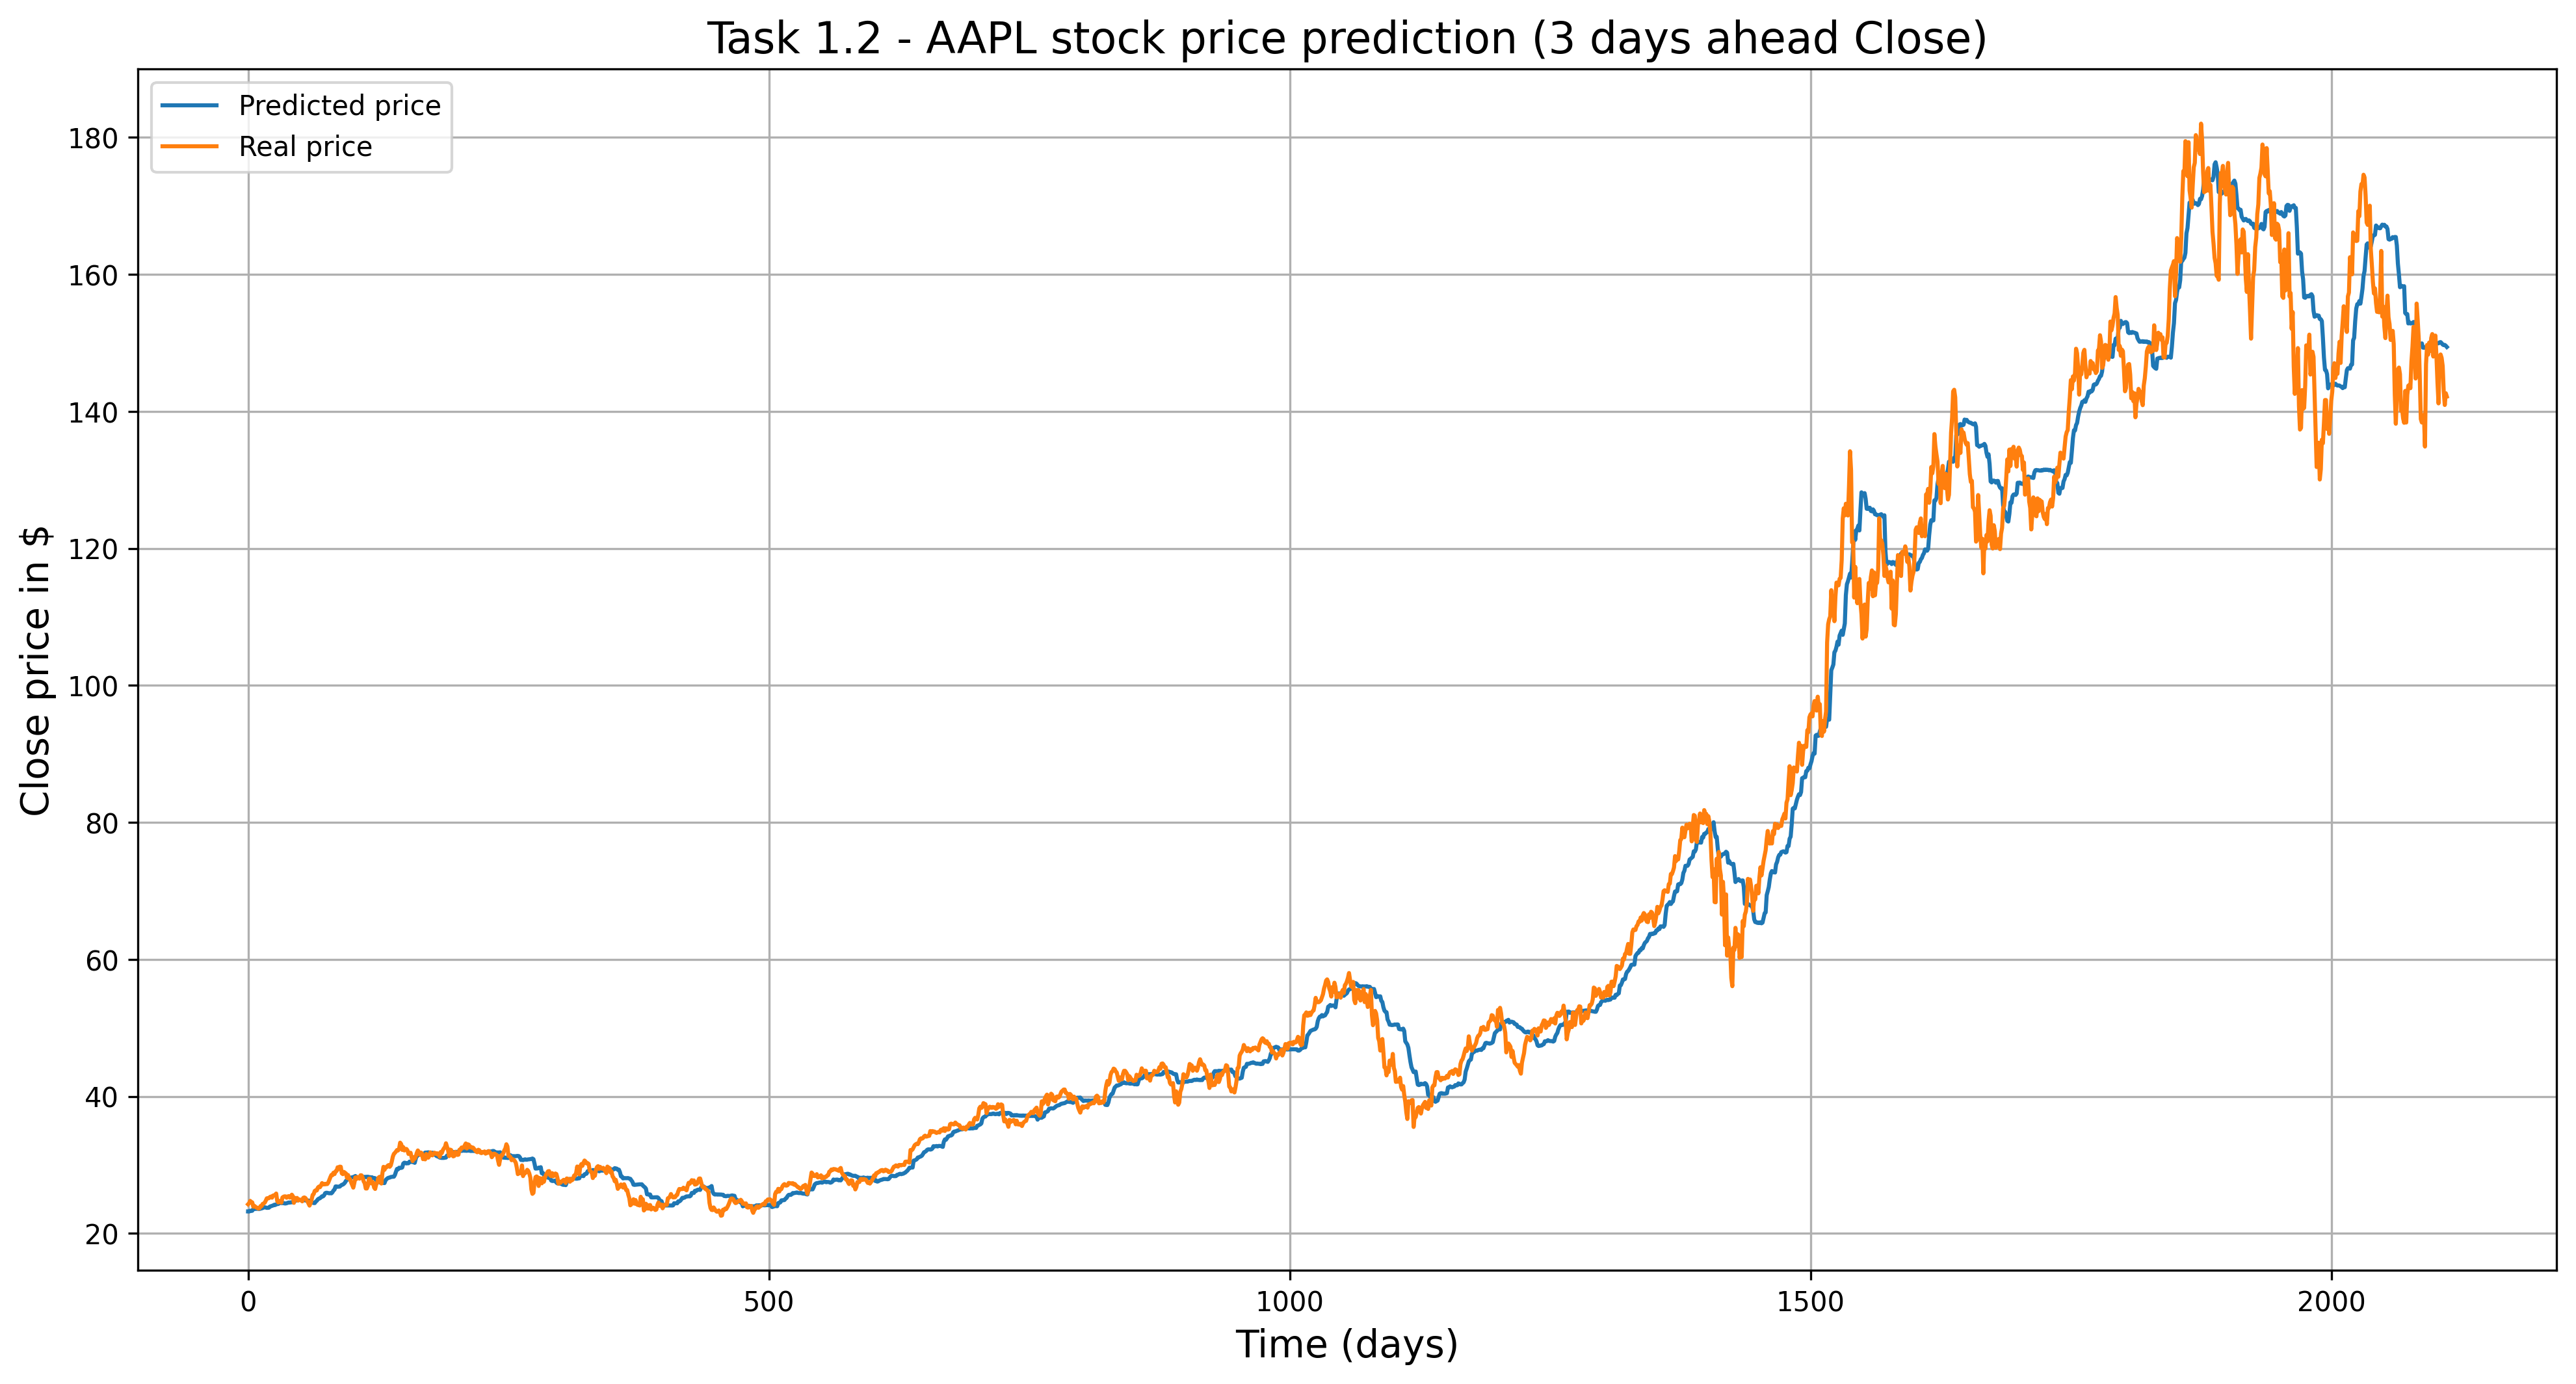

In [ ]:
# Convert the result back to stock price for visualization
y_pred_denorm_12 = per_window_denormalize(y_pred_norm_12, X_test)
y_test_denorm_12 = per_window_denormalize(y_test_norm,    X_test)

plt.figure(figsize=(16, 8), dpi=300)
plt.plot(y_pred_denorm_12, label='Predicted price')
plt.plot(y_test_denorm_12, label='Real price')
plt.title(f'Task 1.2 - AAPL stock price prediction ({N} days ahead Close)', fontsize=16)
plt.xlabel('Time (days)', fontsize=14)
plt.ylabel('Close price in $', fontsize=14)
plt.grid()
plt.legend()
plt.show()

# Task 1.3 - K consecutive days ahead forecast

Extend the model to predict K consecutive days ahead in a single forward pass. The output layer changes from Dense(1) to Dense(K).

In [ ]:
### Window creation with K consecutive day labels
K = 3  # Predict K consecutive days (change to 7 for 7-day prediction)

X_data = []
y_data = []

# Range adjusted by K to avoid going out of bounds
for i in range(1, len(df) - window_size - K):
    data_feature = []
    data_label = []

    for j in range(window_size):
        data_feature.append(df.iloc[i + j, feature_indices].values)

    # Label is now K consecutive days of Close prices
    for k in range(K):
        data_label.append(df.iloc[i + window_size + k]['Close'])

    X_data.append(np.array(data_feature).reshape(window_size, len(features)))
    y_data.append(np.array(data_label))

In [ ]:
### Split, reshape and normalize
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, shuffle=False)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, shuffle=False)

X_train = np.array(X_train); X_val = np.array(X_val); X_test = np.array(X_test)
y_train = np.array(y_train); y_val = np.array(y_val); y_test = np.array(y_test)

X_train = X_train.reshape(X_train.shape[0], window_size, len(features))
X_val   = X_val.reshape(X_val.shape[0],   window_size, len(features))
X_test  = X_test.reshape(X_test.shape[0],  window_size, len(features))

X_train_norm, y_train_norm = per_window_normalize(X_train, y_train)
X_val_norm,   y_val_norm   = per_window_normalize(X_val,   y_val)
X_test_norm,  y_test_norm  = per_window_normalize(X_test,  y_test)

print("Shape of training set:   ", X_train.shape)
print("Shape of validation set: ", X_val.shape)
print("y shape (now K values):  ", y_train.shape)

Shape of training set:    (6755, 30, 6)
Shape of validation set:  (1689, 30, 6)
y shape (now K values):   (6755, 3)


In [ ]:
### Create and train the model for Task 1.3
# Output layer is Dense(K) instead of Dense(1) to predict K days at once
model_13 = build_model(num_outputs=K)
history_13 = model_13.fit(X_train_norm, y_train_norm,
                          validation_data=(X_val_norm, y_val_norm),
                          epochs=5, batch_size=512)

Epoch 1/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 156ms/step - loss: 0.4079 - mse: 0.4079 - val_loss: 0.1112 - val_mse: 0.1112
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - loss: 0.0629 - mse: 0.0629 - val_loss: 0.0385 - val_mse: 0.0385
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0355 - mse: 0.0355 - val_loss: 0.0175 - val_mse: 0.0175
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - loss: 0.0192 - mse: 0.0192 - val_loss: 0.0131 - val_mse: 0.0131
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - loss: 0.0167 - mse: 0.0167 - val_loss: 0.0116 - val_mse: 0.0116


In [ ]:
### Get prediction on the test data
y_pred_norm_13 = model_13.predict(X_test_norm)
mse_13 = mean_squared_error(y_pred_norm_13, y_test_norm)
rmse_13_norm = np.sqrt(mse_13)
print(f"Predicting {K} consecutive days ahead")
print("MSE on the test set:  ", mse_13)
print("RMSE on the test set: ", rmse_13_norm)

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Predicting 3 consecutive days ahead
MSE on the test set:   0.024462471631545413
RMSE on the test set:  0.1564048325070086


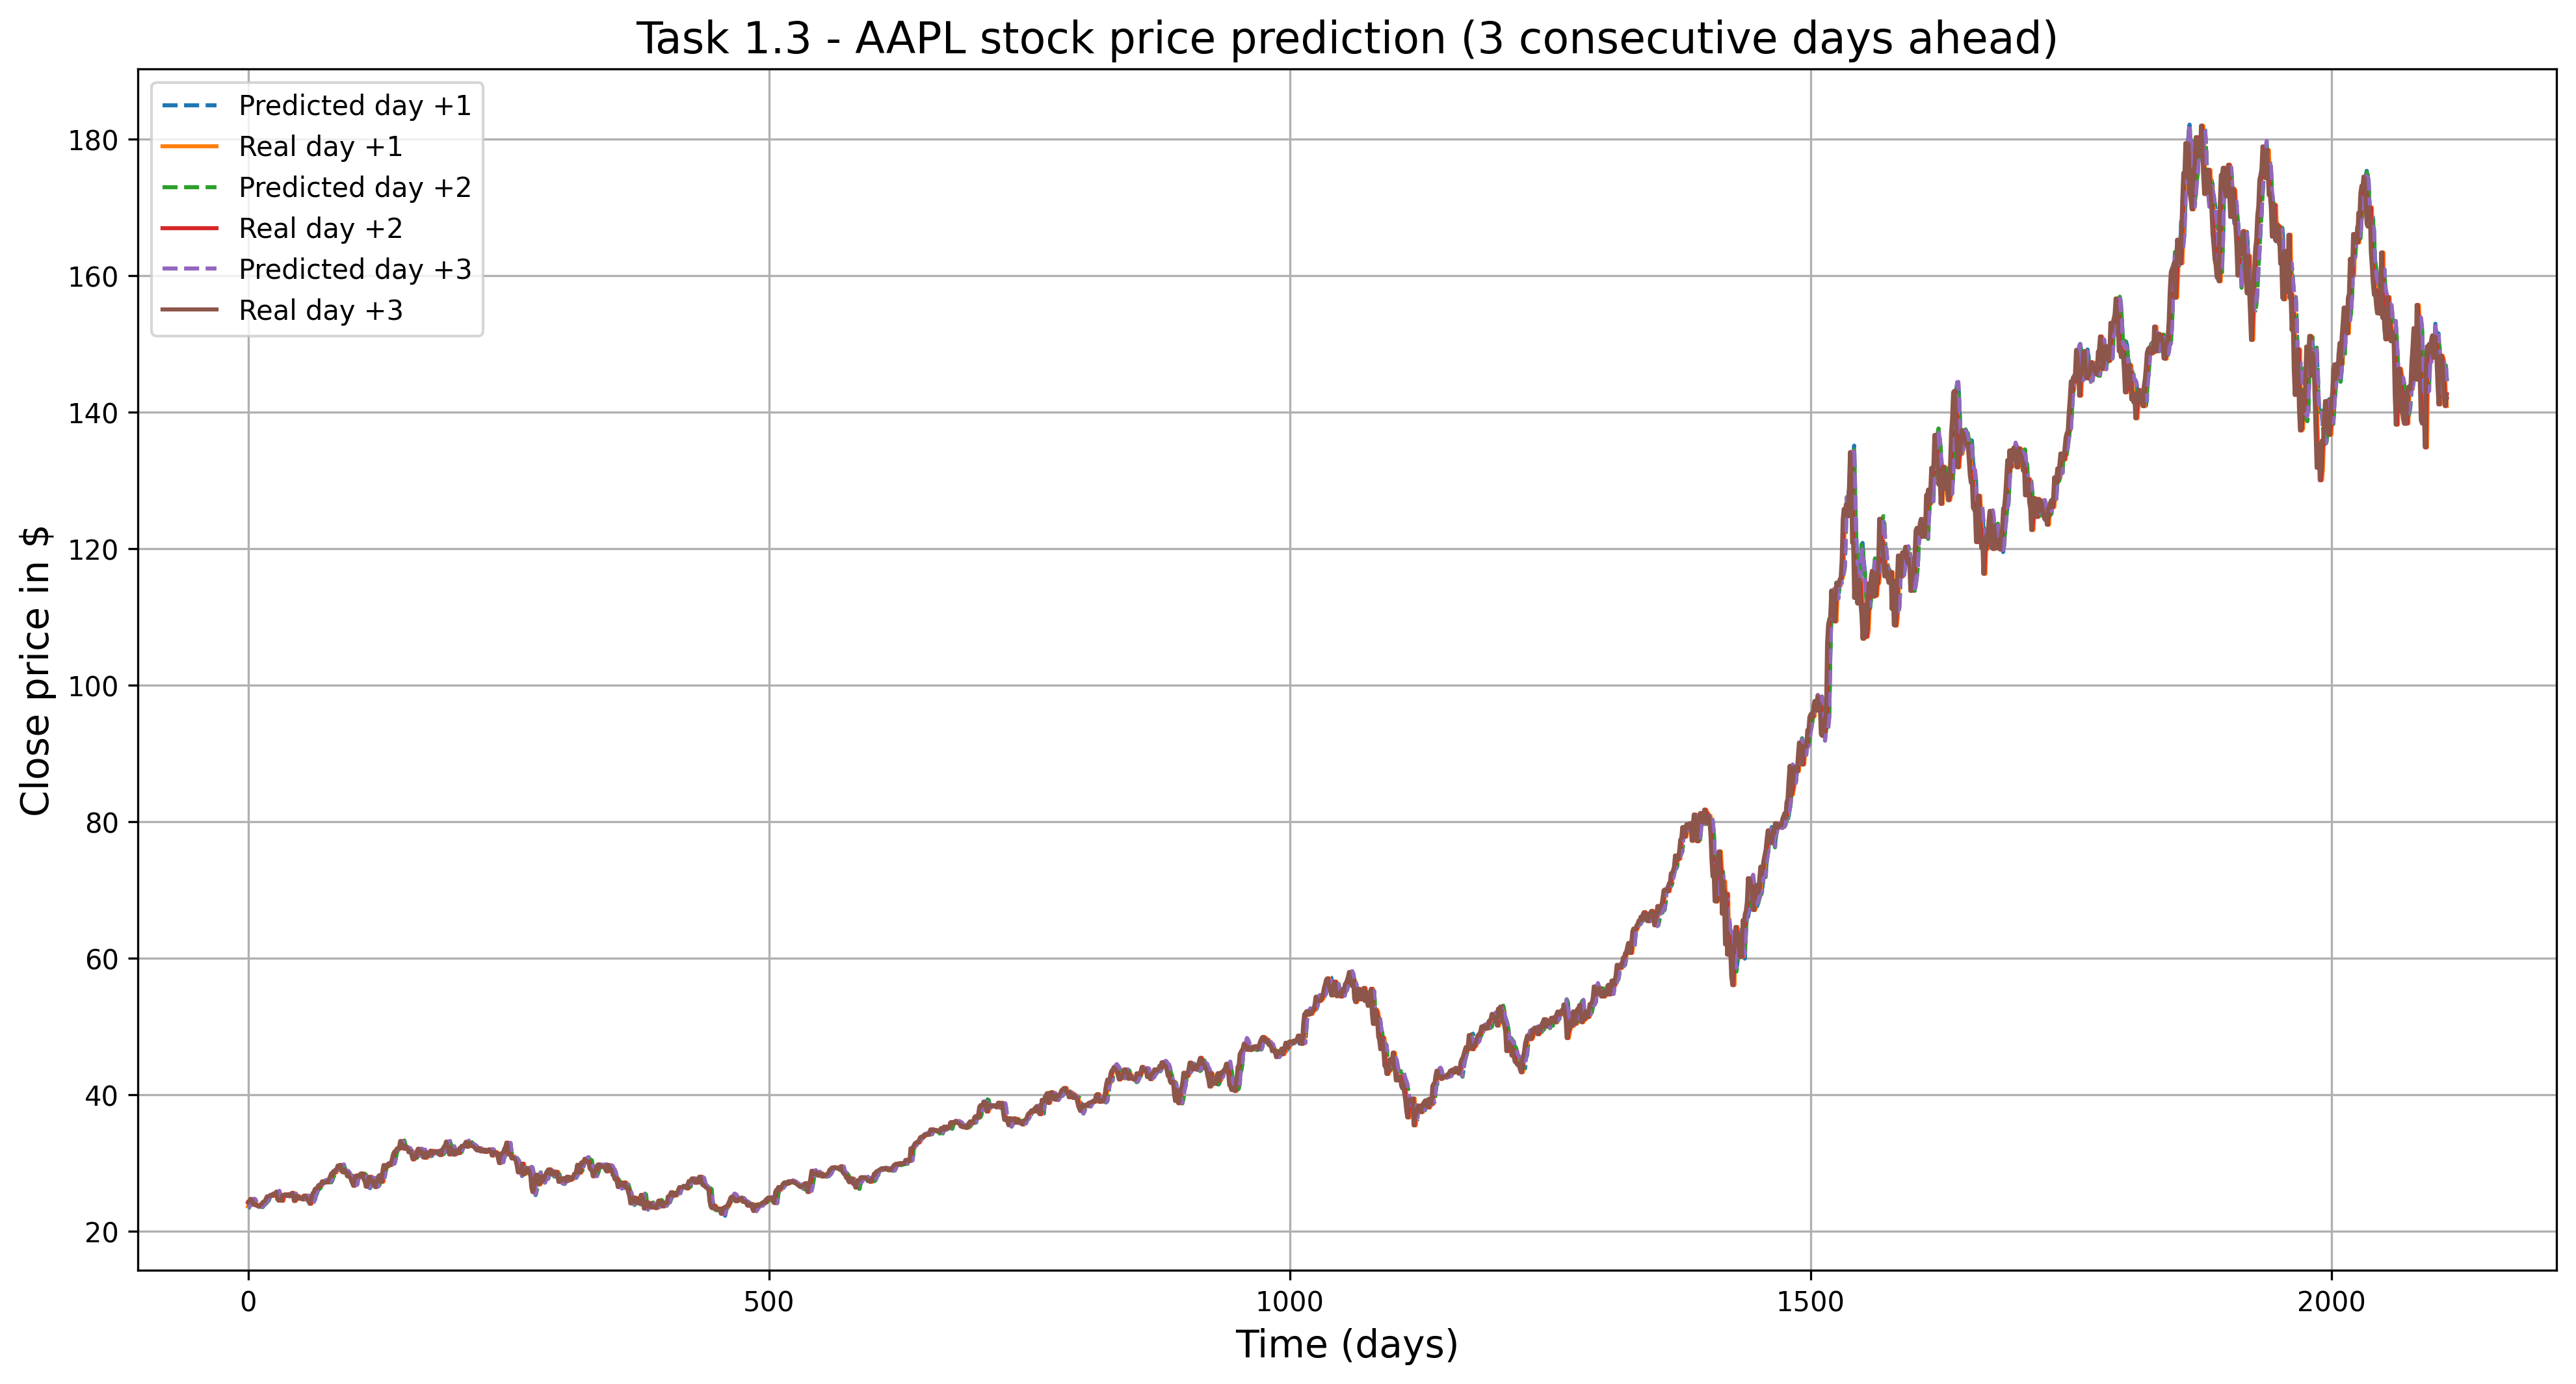

In [ ]:
# De-normalize and plot all K predicted days vs real
y_pred_denorm_13 = per_window_denormalize(y_pred_norm_13, X_test)
y_test_denorm_13 = per_window_denormalize(y_test_norm,    X_test)

plt.figure(figsize=(16, 8), dpi=300)
for k in range(K):
    plt.plot(y_pred_denorm_13[:, k], label=f'Predicted day +{k+1}', linestyle='--')
    plt.plot(y_test_denorm_13[:, k], label=f'Real day +{k+1}')

plt.title(f'Task 1.3 - AAPL stock price prediction ({K} consecutive days ahead)', fontsize=16)
plt.xlabel('Time (days)', fontsize=14)
plt.ylabel('Close price in $', fontsize=14)
plt.grid()
plt.legend()
plt.show()

# Task 1 Comparison

Comparing MSE and RMSE across the three task variants.

In [ ]:
results = pd.DataFrame({
    'Task':       ['1.1 - Next day',     f'1.2 - {N}th day ahead', f'1.3 - {K} days ahead'],
    'MSE (norm)': [mse_11,                mse_12,                   mse_13],
    'RMSE (norm)':[rmse_11_norm,          rmse_12_norm,             rmse_13_norm],
})
print(results.to_string(index=False))

# Score each day separately to see which days are easy vs hard
for k in range(K):
    mse_day_k = mean_squared_error(y_pred_norm_13[:, k], y_test_norm[:, k])
    print(f"Day +{k+1} MSE: {mse_day_k:.4f}")

               Task  MSE (norm)  RMSE (norm)
     1.1 - Next day    0.016347     0.127857
1.2 - 3th day ahead    0.100538     0.317077
 1.3 - 3 days ahead    0.024462     0.156405
Day +1 MSE: 0.0142
Day +2 MSE: 0.0248
Day +3 MSE: 0.0344


# Task 2 - Vietnam stock price prediction

This section applies the same modeling approach from Task 1 to a Vietnamese stock (VIC - Vingroup) from the VN-INDEX.

In [4]:
# Load VIC (Vingroup) data
data_vic = pd.read_csv('/content/drive/MyDrive/selected_stocks/VIC-VNINDEX-History.csv')
data_vic.head()

,Unnamed: 0,Open,High,Low,Close,Volume,TradingDate
0,0,4878.0,4878.0,4878.0,4878.0,307840,2007-09-19
1,1,5112.0,5112.0,5073.0,5112.0,794790,2007-09-20
2,2,5346.0,5346.0,5268.0,5346.0,1224660,2007-09-21
3,3,5581.0,5581.0,5581.0,5581.0,551130,2007-09-24
4,4,5854.0,5854.0,5776.0,5854.0,962110,2007-09-25


In [5]:
# Get some info about the Vietnam data
data_vic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3850 entries, 0 to 3849
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   3850 non-null   int64  
 1   Open         3850 non-null   float64
 2   High         3850 non-null   float64
 3   Low          3850 non-null   float64
 4   Close        3850 non-null   float64
 5   Volume       3850 non-null   int64  
 6   TradingDate  3850 non-null   object 
dtypes: float64(4), int64(2), object(1)
memory usage: 210.7+ KB


In [6]:
# Shared parameters for Task 2
# Note: Vietnam data does not include 'Adjusted Close', so features list has 5 items instead of 6
df_vn = data_vic
features_vn = ['Open', 'High', 'Low', 'Close', 'Volume']
feature_indices_vn = [df_vn.columns.get_loc(f) for f in features_vn]

## Task 2 helper functions

Same logic as Task 1's helpers, but adjusted for 5 features (4 prices + Volume) instead of 6.

In [7]:
def per_window_normalize_vn(X, y):
    """Per-window MinMax normalization for Vietnam data (4 price cols + 1 volume col)."""
    X_norm = X.copy().astype(float)
    y_norm = y.copy().astype(float)
    for i in range(len(X)):
        # Price columns (first 4: Open, High, Low, Close)
        min_f = np.min(X[i, :, :4])
        max_f = np.max(X[i, :, :4])
        X_norm[i, :, :4] = (X[i, :, :4] - min_f) / (max_f - min_f)
        # Volume column (last)
        vol_min = np.min(X[i, :, 4])
        vol_max = np.max(X[i, :, 4])
        if vol_max - vol_min != 0:
            X_norm[i, :, 4] = (X[i, :, 4] - vol_min) / (vol_max - vol_min)
        # Label normalized using price min/max
        y_norm[i] = (y[i] - min_f) / (max_f - min_f)
    return X_norm, y_norm


def per_window_denormalize_vn(y_norm, X_original):
    """Reverse per-window normalization for Vietnam data."""
    y_denorm = y_norm.copy()
    for i in range(len(y_denorm)):
        min_f = np.min(X_original[i, :, :4])
        max_f = np.max(X_original[i, :, :4])
        y_denorm[i] = y_norm[i] * (max_f - min_f) + min_f
    return y_denorm


def build_model_vn(num_outputs):
    """Build the same Conv1D model architecture but for Vietnam data (5 features)."""
    model = tf.keras.Sequential()
    model.add(Input(shape=(window_size, len(features_vn))))
    model.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(2))
    model.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(2))
    model.add(Flatten())
    model.add(Dense(100, activation='relu'))
    model.add(Dense(num_outputs))
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                  loss='mse', metrics=['mse'])
    return model

# Task 2.1 - Vietnam multi-feature extension

Apply the multi-feature approach from Task 1.1 to VIC. The Vietnam data uses 5 features since Adjusted Close is not provided.

In [45]:
### Split the dataset into time windows to get data samples
X_data = []
y_data = []
window_size = 30

for i in range(1, len(df_vn) - window_size - 1):
    data_feature = []
    data_label = []

    # Get a window_size time frame for data feature (5 features for Vietnam)
    for j in range(window_size):
        data_feature.append(df_vn.iloc[i + j, feature_indices_vn].values)

    # Next value is the label (Close price of the next day) to be predicted
    data_label.append(df_vn.iloc[i + window_size]['Close'])

    X_data.append(np.array(data_feature).reshape(window_size, len(features_vn)))
    y_data.append(np.array(data_label))

In [47]:
### Split the data into training, validation and test set
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, shuffle=False)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, shuffle=False)

X_train = np.array(X_train); X_val = np.array(X_val); X_test = np.array(X_test)
y_train = np.array(y_train); y_val = np.array(y_val); y_test = np.array(y_test)

X_train = X_train.reshape(X_train.shape[0], window_size, len(features_vn))
X_val   = X_val.reshape(X_val.shape[0],   window_size, len(features_vn))
X_test  = X_test.reshape(X_test.shape[0],  window_size, len(features_vn))

print("Shape of training set:   ", X_train.shape)
print("Shape of validation set: ", X_val.shape)
print("Shape of test set:       ", X_test.shape)

Shape of training set:    (2443, 30, 5)
Shape of validation set:  (611, 30, 5)
Shape of test set:        (764, 30, 5)


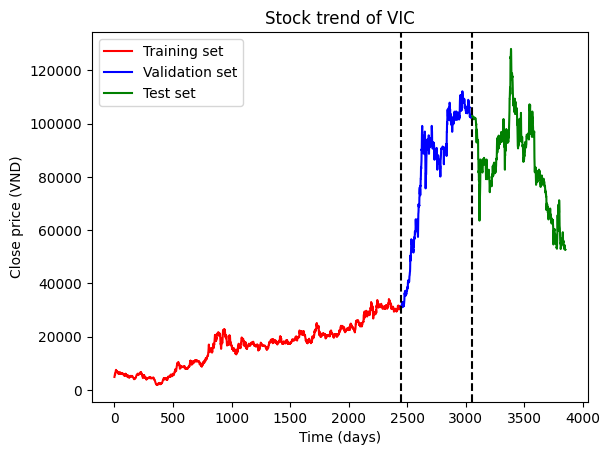

In [48]:
# Visualize the training, validation and test set splits
df_plot = df_vn['Close'].reset_index(drop=False)
size_train = X_train.shape[0]
size_val = X_val.shape[0]

ax = df_plot.iloc[:size_train, 1:2].plot(y=0, color='red', label='Training set')
df_plot.iloc[size_train:size_train+size_val, 1:2].plot(y=0, color='blue', label='Validation set', ax=ax)
df_plot.iloc[size_train+size_val:, 1:2].plot(y=0, color='green', label='Test set', ax=ax)
ax.set_title("Stock trend of VIC")
plt.xlabel('Time (days)')
plt.ylabel('Close price (VND)')
plt.axvline(x=size_train, color='black', linestyle='--')
plt.axvline(x=size_train+size_val, color='black', linestyle='--')
plt.show()

In [49]:
# Per-window normalization (Vietnam version)
X_train_norm, y_train_norm = per_window_normalize_vn(X_train, y_train)
X_val_norm,   y_val_norm   = per_window_normalize_vn(X_val,   y_val)
X_test_norm,  y_test_norm  = per_window_normalize_vn(X_test,  y_test)

In [50]:
### Create and train the model for Task 2.1
model_21 = build_model_vn(num_outputs=1)
history_21 = model_21.fit(X_train_norm, y_train_norm,
                          validation_data=(X_val_norm, y_val_norm),
                          epochs=15, batch_size=512)

Epoch 1/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - loss: 2.9307 - mse: 2.9307 - val_loss: 0.3853 - val_mse: 0.3853
Epoch 2/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.2107 - mse: 0.2107 - val_loss: 0.1148 - val_mse: 0.1148
Epoch 3/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.1303 - mse: 0.1303 - val_loss: 0.1384 - val_mse: 0.1384
Epoch 4/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.1171 - mse: 0.1171 - val_loss: 0.0892 - val_mse: 0.0892
Epoch 5/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.1125 - mse: 0.1125 - val_loss: 0.0968 - val_mse: 0.0968
Epoch 6/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.1059 - mse: 0.1059 - val_loss: 0.0874 - val_mse: 0.0874
Epoch 7/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.1042 - mse: 0.1042 - val_loss: 0.0939 - val_mse: 0.0939
Epoch 8/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.1018 - mse: 0.1018 - val_loss: 0.1002 - val_mse: 0.1002
Epoch 9/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.1004 - mse: 0.1004 -

In [51]:
### Get prediction on the test data
y_pred_norm_21 = model_21.predict(X_test_norm)
mse_21 = mean_squared_error(y_pred_norm_21, y_test_norm)
rmse_21_norm = np.sqrt(mse_21)
print("MSE on the test set:  ", mse_21)
print("RMSE on the test set: ", rmse_21_norm)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
MSE on the test set:   0.04859476832412964
RMSE on the test set:  0.22044221084930546


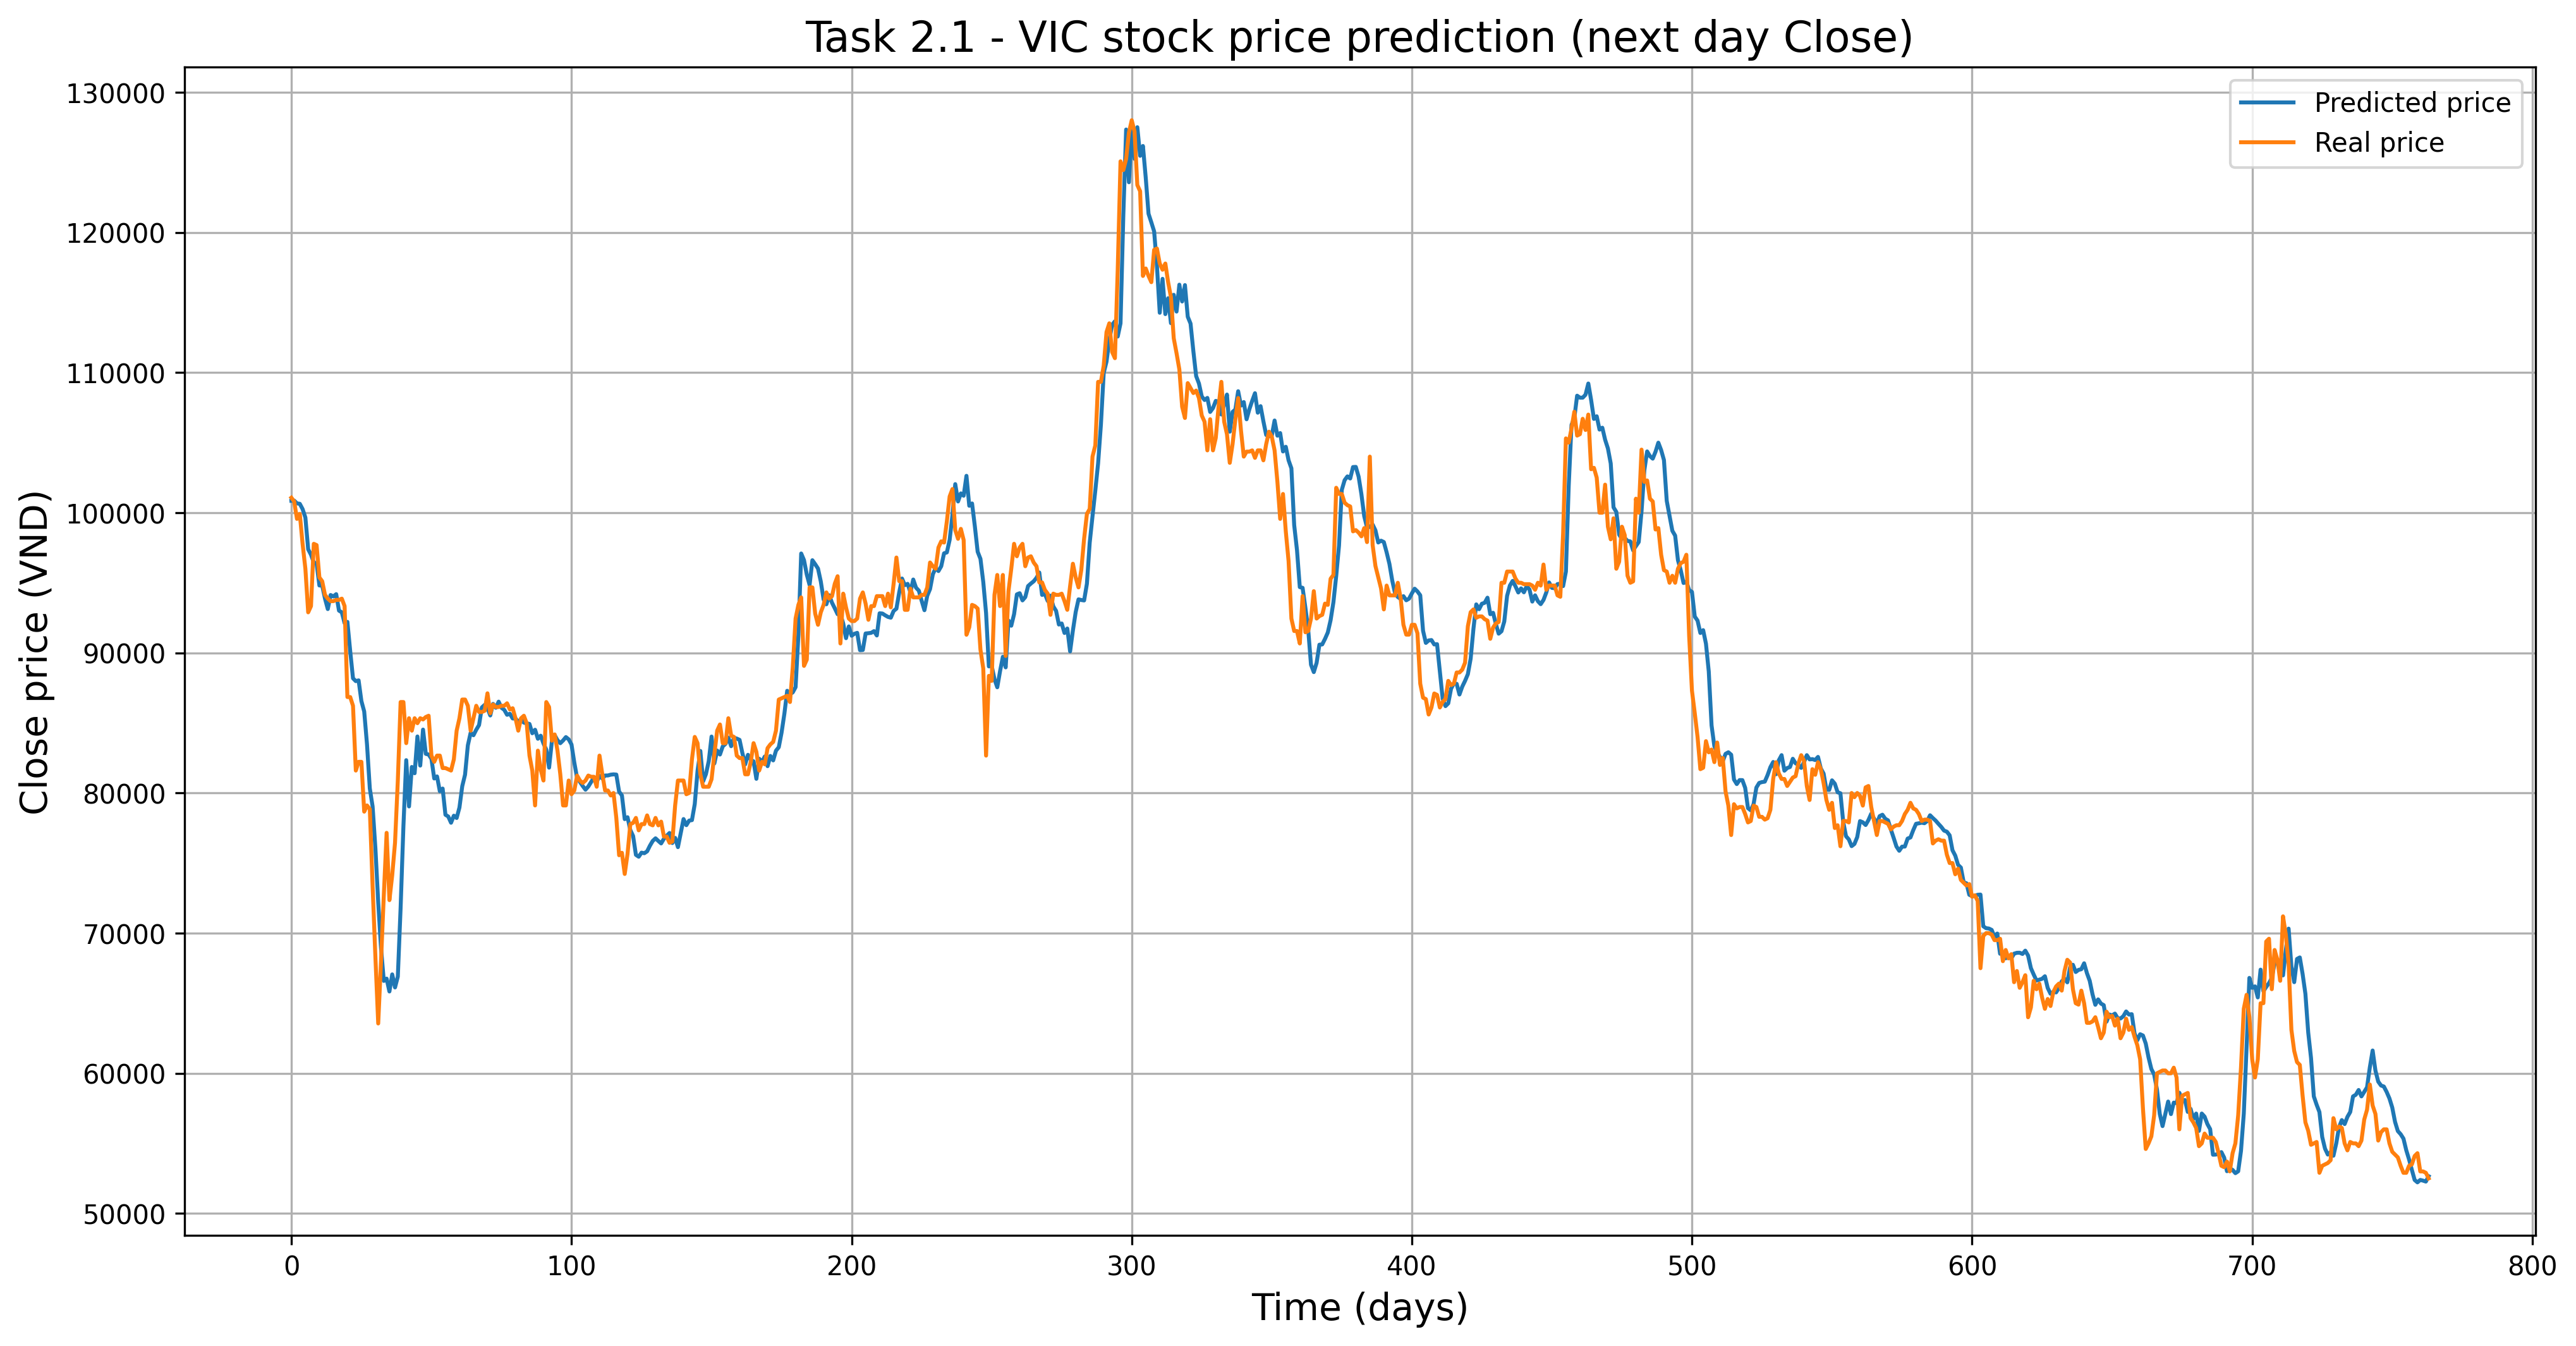

In [52]:
# Convert the result back to stock price for visualization
y_pred_denorm_21 = per_window_denormalize_vn(y_pred_norm_21, X_test)
y_test_denorm_21 = per_window_denormalize_vn(y_test_norm,    X_test)

plt.figure(figsize=(16, 8), dpi=300)
plt.plot(y_pred_denorm_21, label='Predicted price')
plt.plot(y_test_denorm_21, label='Real price')
plt.title('Task 2.1 - VIC stock price prediction (next day Close)', fontsize=16)
plt.xlabel('Time (days)', fontsize=14)
plt.ylabel('Close price (VND)', fontsize=14)
plt.grid()
plt.legend()
plt.show()

# Task 2.2 - Vietnam Nth day ahead forecast

Apply Task 1.2's Nth day prediction approach to VIC.

In [18]:
### Window creation with Nth day label
N = 3  # Predict the Nth day ahead (change to 7 for 7th day prediction)

X_data = []
y_data = []

for i in range(1, len(df_vn) - window_size - N):
    data_feature = []
    data_label = []

    for j in range(window_size):
        data_feature.append(df_vn.iloc[i + j, feature_indices_vn].values)

    # Label is the Close price on the Nth day ahead
    data_label.append(df_vn.iloc[i + window_size + N - 1]['Close'])

    X_data.append(np.array(data_feature).reshape(window_size, len(features_vn)))
    y_data.append(np.array(data_label))

In [19]:
### Split, reshape and normalize (identical structure to Task 2.1)
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, shuffle=False)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, shuffle=False)

X_train = np.array(X_train); X_val = np.array(X_val); X_test = np.array(X_test)
y_train = np.array(y_train); y_val = np.array(y_val); y_test = np.array(y_test)

X_train = X_train.reshape(X_train.shape[0], window_size, len(features_vn))
X_val   = X_val.reshape(X_val.shape[0],   window_size, len(features_vn))
X_test  = X_test.reshape(X_test.shape[0],  window_size, len(features_vn))

X_train_norm, y_train_norm = per_window_normalize_vn(X_train, y_train)
X_val_norm,   y_val_norm   = per_window_normalize_vn(X_val,   y_val)
X_test_norm,  y_test_norm  = per_window_normalize_vn(X_test,  y_test)

print("Shape of training set:   ", X_train.shape)
print("Shape of validation set: ", X_val.shape)
print("Shape of test set:       ", X_test.shape)

Shape of training set:    (2441, 30, 5)
Shape of validation set:  (611, 30, 5)
Shape of test set:        (764, 30, 5)


In [53]:
### Create and train the model for Task 2.2
model_22 = build_model_vn(num_outputs=1)
history_22 = model_22.fit(X_train_norm, y_train_norm,
                          validation_data=(X_val_norm, y_val_norm),
                          epochs=15, batch_size=512)

Epoch 1/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - loss: 1.9778 - mse: 1.9778 - val_loss: 0.4645 - val_mse: 0.4645
Epoch 2/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.3417 - mse: 0.3417 - val_loss: 0.2917 - val_mse: 0.2917
Epoch 3/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.1571 - mse: 0.1571 - val_loss: 0.1124 - val_mse: 0.1124
Epoch 4/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.1473 - mse: 0.1473 - val_loss: 0.0962 - val_mse: 0.0962
Epoch 5/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - loss: 0.1132 - mse: 0.1132 - val_loss: 0.1354 - val_mse: 0.1354
Epoch 6/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step - loss: 0.1183 - mse: 0.1183 - val_loss: 0.1090 - val_mse: 0.1090
Epoch 7/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - loss: 0.1069 - mse: 0.1069 - val_loss: 0.0900 - val_mse: 0.0900
Epoch 8/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - loss: 0.1103 - mse: 0.1103 - val_loss: 0.0920 - val_mse: 0.0920
Epoch 9/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.1065 - mse: 0.106

In [54]:
### Get prediction on the test data
y_pred_norm_22 = model_22.predict(X_test_norm)
mse_22 = mean_squared_error(y_pred_norm_22, y_test_norm)
rmse_22_norm = np.sqrt(mse_22)
print(f"Predicting {N} days ahead")
print("MSE on the test set:  ", mse_22)
print("RMSE on the test set: ", rmse_22_norm)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Predicting 3 days ahead
MSE on the test set:   0.11588151158839587
RMSE on the test set:  0.3404137358985325


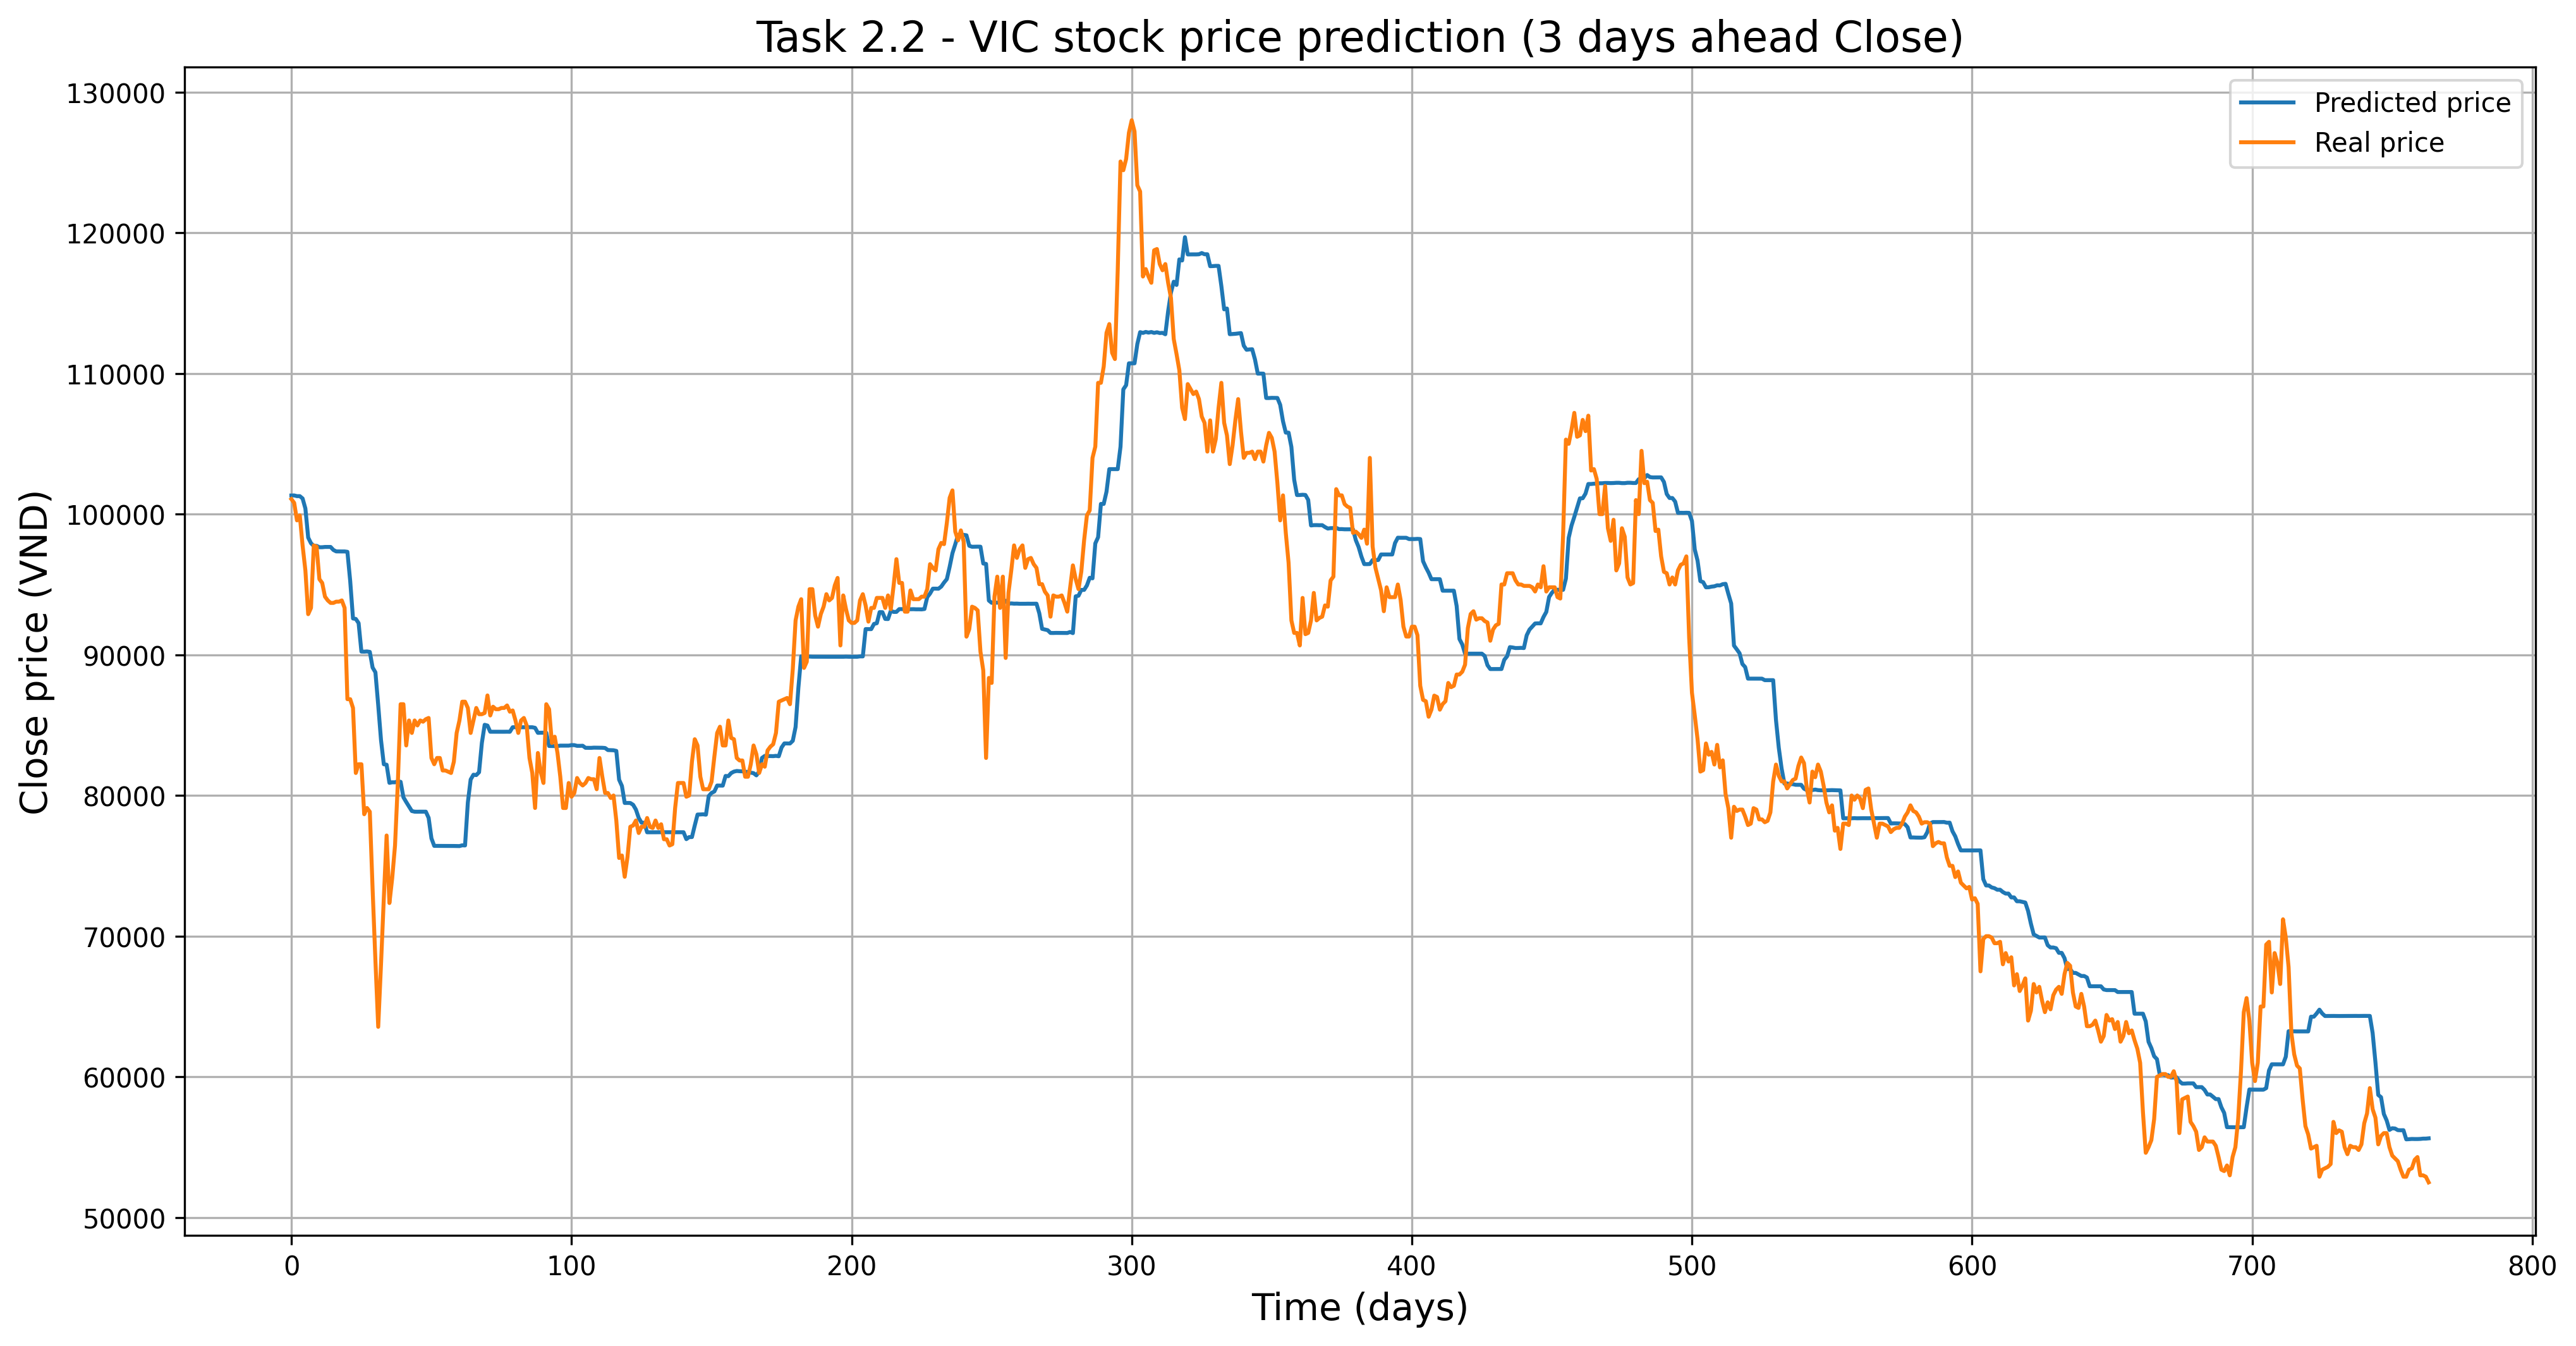

In [55]:
# Convert the result back to stock price for visualization
y_pred_denorm_22 = per_window_denormalize_vn(y_pred_norm_22, X_test)
y_test_denorm_22 = per_window_denormalize_vn(y_test_norm,    X_test)

plt.figure(figsize=(16, 8), dpi=300)
plt.plot(y_pred_denorm_22, label='Predicted price')
plt.plot(y_test_denorm_22, label='Real price')
plt.title(f'Task 2.2 - VIC stock price prediction ({N} days ahead Close)', fontsize=16)
plt.xlabel('Time (days)', fontsize=14)
plt.ylabel('Close price (VND)', fontsize=14)
plt.grid()
plt.legend()
plt.show()

# Task 2.3 - Vietnam K consecutive days ahead forecast

Apply Task 1.3's K-day prediction approach to VIC. Output layer becomes Dense(K) instead of Dense(1).

In [60]:
### Window creation with K consecutive day labels
K = 3  # Predict K consecutive days (change to 7 for 7-day prediction)

X_data = []
y_data = []

for i in range(1, len(df_vn) - window_size - K):
    data_feature = []
    data_label = []

    for j in range(window_size):
        data_feature.append(df_vn.iloc[i + j, feature_indices_vn].values)

    # Label is now K consecutive days of Close prices
    for k in range(K):
        data_label.append(df_vn.iloc[i + window_size + k]['Close'])

    X_data.append(np.array(data_feature).reshape(window_size, len(features_vn)))
    y_data.append(np.array(data_label))

In [61]:
### Split, reshape and normalize
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, shuffle=False)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, shuffle=False)

X_train = np.array(X_train); X_val = np.array(X_val); X_test = np.array(X_test)
y_train = np.array(y_train); y_val = np.array(y_val); y_test = np.array(y_test)

X_train = X_train.reshape(X_train.shape[0], window_size, len(features_vn))
X_val   = X_val.reshape(X_val.shape[0],   window_size, len(features_vn))
X_test  = X_test.reshape(X_test.shape[0],  window_size, len(features_vn))

X_train_norm, y_train_norm = per_window_normalize_vn(X_train, y_train)
X_val_norm,   y_val_norm   = per_window_normalize_vn(X_val,   y_val)
X_test_norm,  y_test_norm  = per_window_normalize_vn(X_test,  y_test)

print("Shape of training set:   ", X_train.shape)
print("Shape of validation set: ", X_val.shape)
print("y shape (now K values):  ", y_train.shape)

Shape of training set:    (2441, 30, 5)
Shape of validation set:  (611, 30, 5)
y shape (now K values):   (2441, 3)


In [57]:
### Create and train the model for Task 2.3
# Output layer is Dense(K) instead of Dense(1) to predict K days at once
model_23 = build_model_vn(num_outputs=K)
history_23 = model_23.fit(X_train_norm, y_train_norm,
                          validation_data=(X_val_norm, y_val_norm),
                          epochs=30, batch_size=512)

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - loss: 0.9887 - mse: 0.9887 - val_loss: 0.4457 - val_mse: 0.4457
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.3311 - mse: 0.3311 - val_loss: 0.2663 - val_mse: 0.2663
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.1669 - mse: 0.1669 - val_loss: 0.0966 - val_mse: 0.0966
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - loss: 0.1176 - mse: 0.1176 - val_loss: 0.1196 - val_mse: 0.1196
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 0.1110 - mse: 0.1110 - val_loss: 0.0897 - val_mse: 0.0897
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.1059 - mse: 0.1059 - val_loss: 0.0962 - val_mse: 0.0962
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.1026 - mse: 0.1026 - val_loss: 0.0873 - val_mse: 0.0873
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0952 - mse: 0.0952 - val_loss: 0.0794 - val_mse: 0.0794
Epoch 9/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0838 - mse: 0.0838 - 

In [62]:
### Get prediction on the test data
y_pred_norm_23 = model_23.predict(X_test_norm)
mse_23 = mean_squared_error(y_pred_norm_23, y_test_norm)
rmse_23_norm = np.sqrt(mse_23)
print(f"Predicting {K} consecutive days ahead")
print("MSE on the test set:  ", mse_23)
print("RMSE on the test set: ", rmse_23_norm)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Predicting 3 consecutive days ahead
MSE on the test set:   0.038219019066998844
RMSE on the test set:  0.19549685180840853


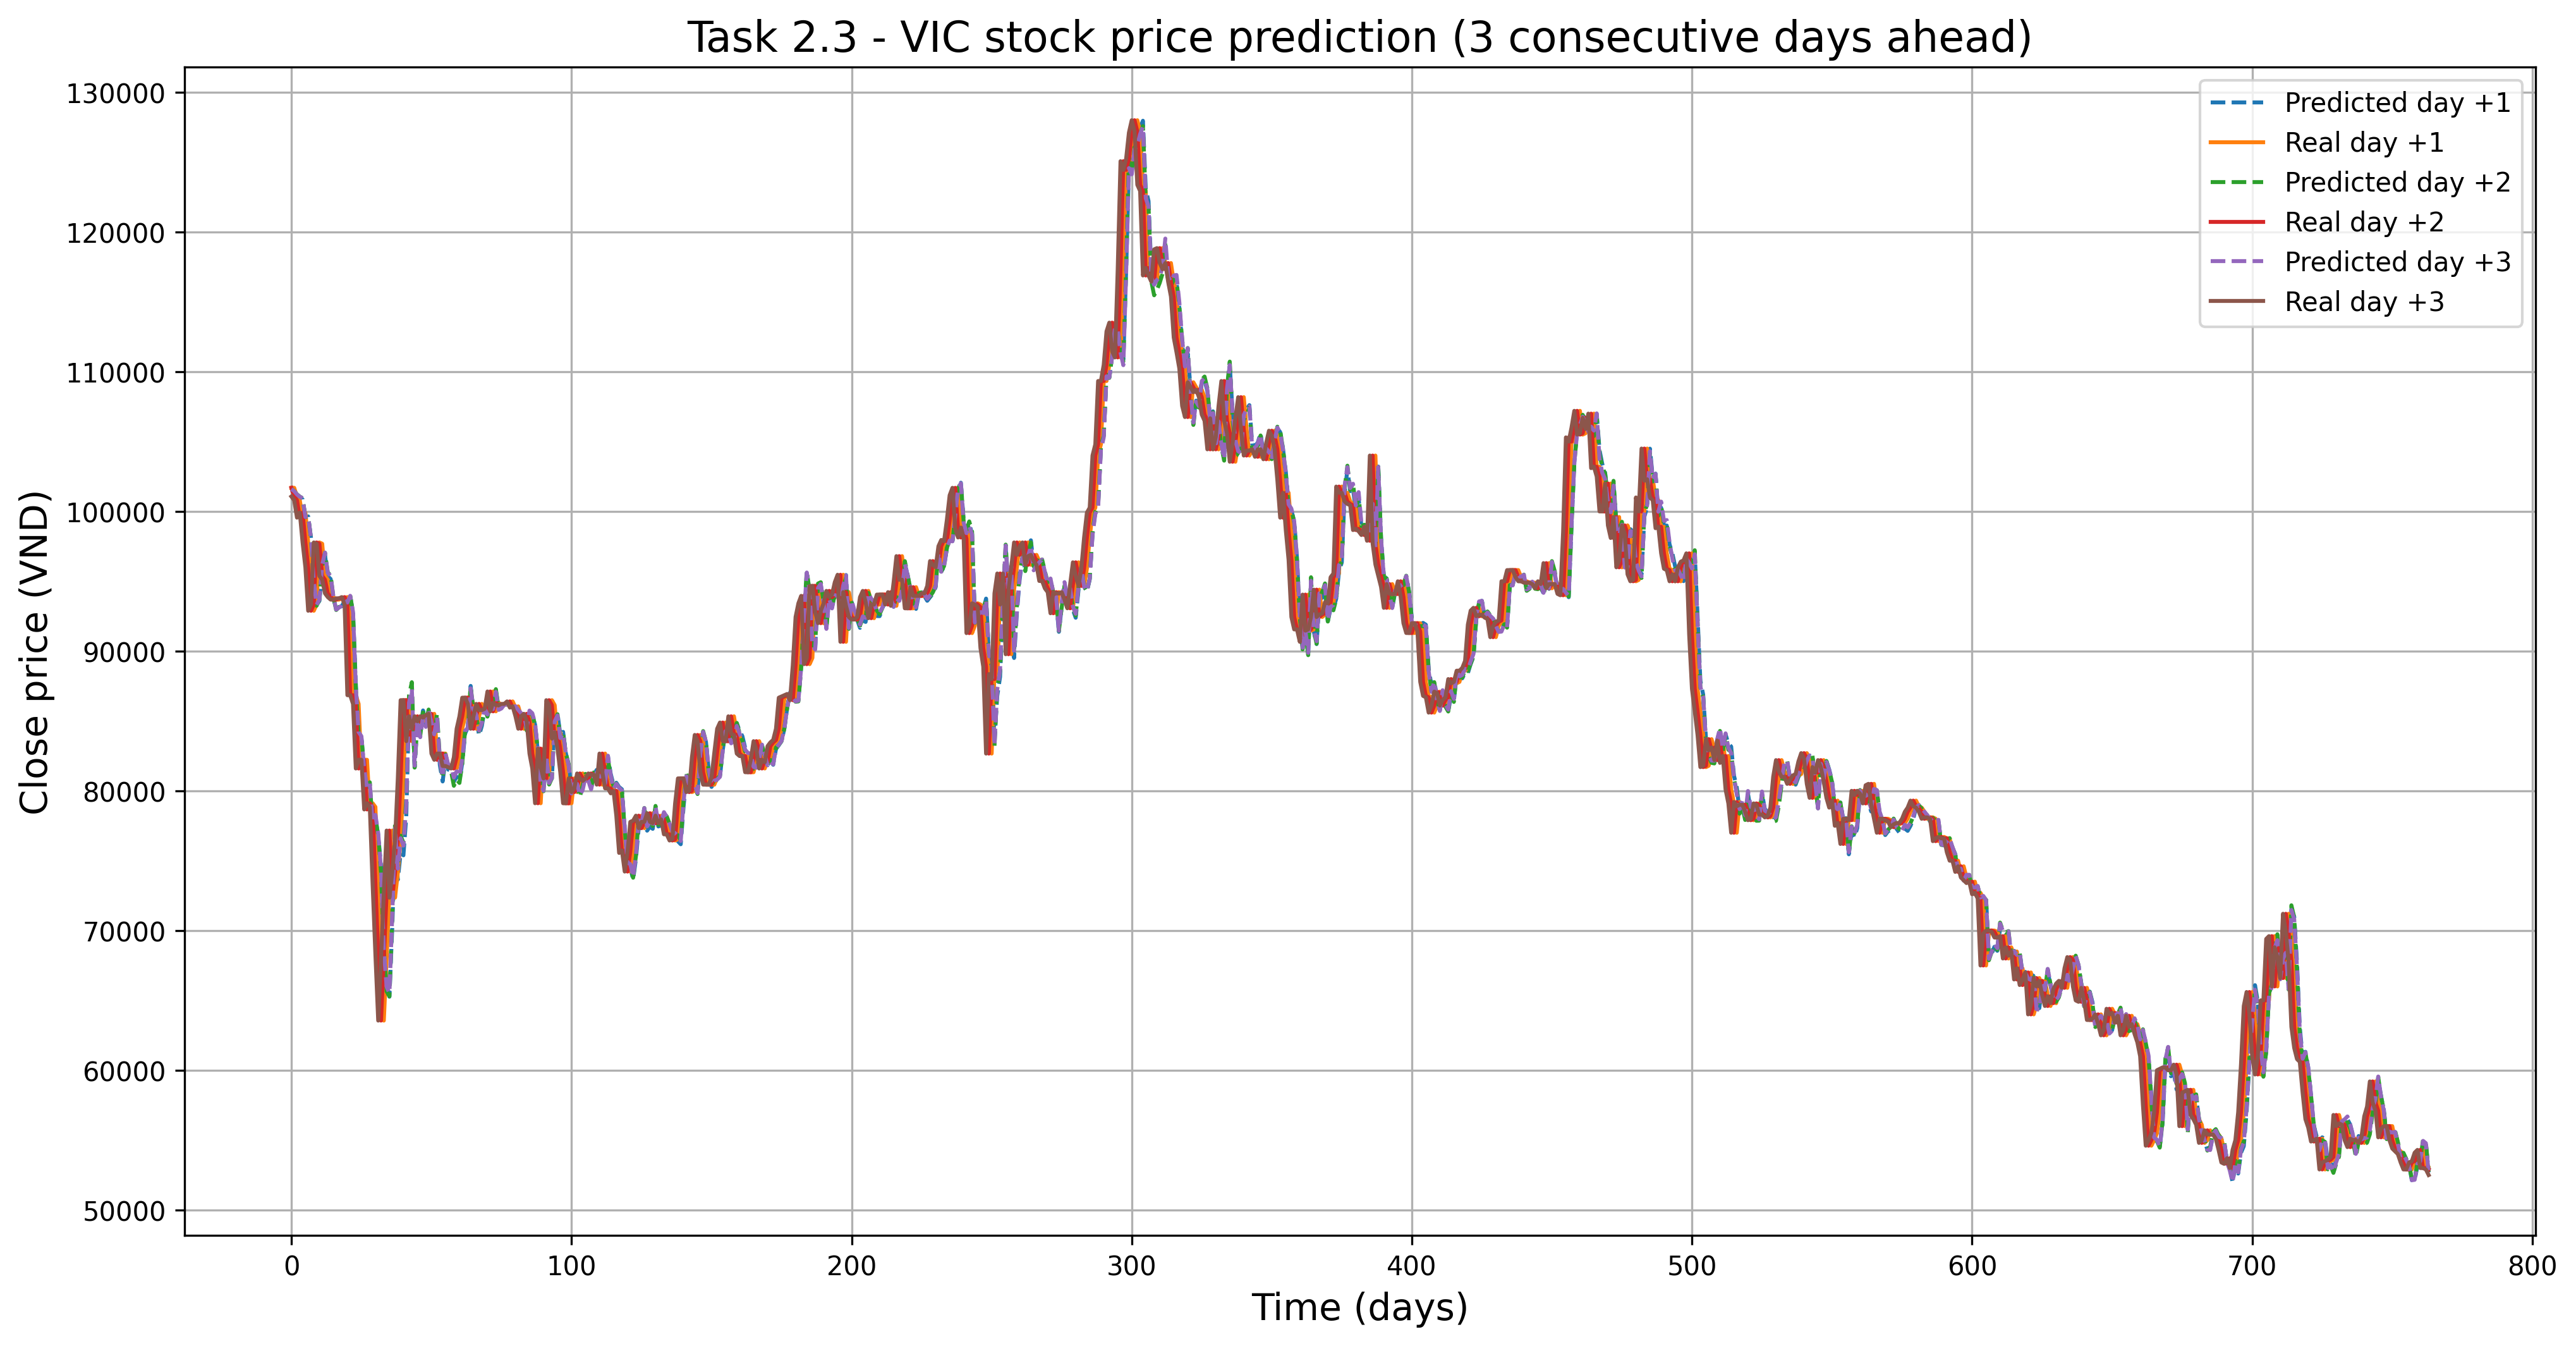

In [63]:
# De-normalize and plot all K predicted days vs real
y_pred_denorm_23 = per_window_denormalize_vn(y_pred_norm_23, X_test)
y_test_denorm_23 = per_window_denormalize_vn(y_test_norm,    X_test)

plt.figure(figsize=(16, 8), dpi=300)
for k in range(K):
    plt.plot(y_pred_denorm_23[:, k], label=f'Predicted day +{k+1}', linestyle='--')
    plt.plot(y_test_denorm_23[:, k], label=f'Real day +{k+1}')

plt.title(f'Task 2.3 - VIC stock price prediction ({K} consecutive days ahead)', fontsize=16)
plt.xlabel('Time (days)', fontsize=14)
plt.ylabel('Close price (VND)', fontsize=14)
plt.grid()
plt.legend()
plt.show()

# Task 2 Comparison

Comparing MSE and RMSE across the three Vietnam task variants.

In [64]:
results_task2 = pd.DataFrame({
    'Task':        ['2.1 - Next day',     f'2.2 - {N}th day ahead', f'2.3 - {K} days ahead'],
    'MSE (norm)':  [mse_21,                mse_22,                   mse_23],
    'RMSE (norm)': [rmse_21_norm,          rmse_22_norm,             rmse_23_norm],
})
print(results_task2.to_string(index=False))

               Task  MSE (norm)  RMSE (norm)
     2.1 - Next day    0.048595     0.220442
2.2 - 3th day ahead    0.115882     0.340414
 2.3 - 3 days ahead    0.038219     0.195497


# Task 3: Trading signal identification for Vietnam market